In [1]:
import cooler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

In [2]:
# Load cooler file
clr = cooler.Cooler("/project/fudenber_735/GEO/Hsieh2019/4DN/mESC_mm10_4DNFILZ1CPT8.mapq_30.8192.cool")

# Load stripes from tsv
tsv_path = "/scratch1/smaruj/stripenn_out/result_filtered.tsv"
stripes_df = pd.read_csv(tsv_path, sep='\t')

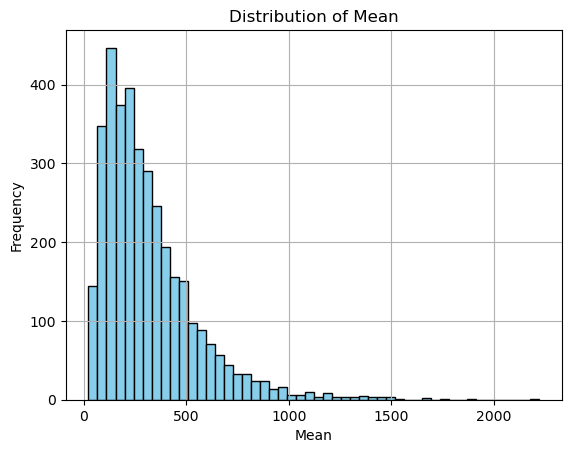

In [3]:
import matplotlib.pyplot as plt

plt.hist(stripes_df['Mean'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Mean')
plt.ylabel('Frequency')
plt.title('Distribution of Mean')
plt.grid(True)
plt.show()

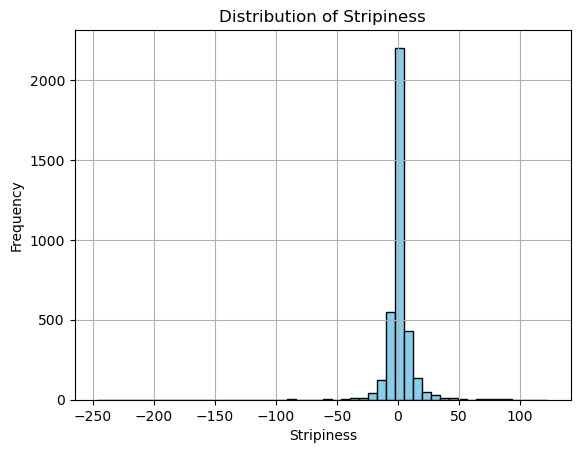

In [4]:
plt.hist(stripes_df['Stripiness'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Stripiness')
plt.ylabel('Frequency')
plt.title('Distribution of Stripiness')
plt.grid(True)
plt.show()

In [5]:
len(stripes_df)

3631

In [6]:
stripes_df.columns

Index(['chr', 'pos1', 'pos2', 'chr2', 'pos3', 'pos4', 'length', 'width',
       'Mean', 'maxpixel', 'pvalue', 'Stripiness'],
      dtype='object')

In [7]:
from tqdm import tqdm

In [8]:
def annotate_missing_fraction_bbox(
    df,
    cool_path,
    res,
    halfwin=5,
    use_pixels=False,
    balance=True,
    show_progress=True
):
    """
    For every (intra-chromosomal) stripe defined by
    (chrom1,start1,end1, chrom2,start2,end2),
    compute the fraction of missing data inside the rectangle defined by:
      [bin(start1)..bin(end1)] x [bin(start2)..bin(end2)]
    expanded by ±halfwin bins on all four sides.

    Missingness:
      - use_pixels=False: based on bins.weight being NaN (fast proxy).
      - use_pixels=True : based on NaN pixels in the (balanced) matrix slice (slower, exact).
    """
    c = cooler.Cooler(cool_path)

    chrom_extents = {chrom: c.extent(chrom) for chrom in c.chromnames}
    if not use_pixels:
        bins = c.bins()[:]
        bad_bins = bins["weight"].isna() if "weight" in bins.columns else pd.Series(False, index=bins.index)

    def pos2bin_start(chrom, pos):
        """0-based bin index for 'start' coordinate."""
        start, _ = chrom_extents[chrom]
        return start + (pos // res)

    def pos2bin_end(chrom, pos):
        """Inclusive bin index for 'end' coordinate (subtract 1 to be in the bin)."""
        start, _ = chrom_extents[chrom]
        return start + ((pos - 1) // res)

    it = df.itertuples(index=False)
    if show_progress:
        it = tqdm(it, total=len(df), desc="Annotating missing fractions (bbox)")

    fracs = []
    for row in it:
        chrom = row.chr
        chrom_start, chrom_end = chrom_extents[chrom]

        # bin ranges for each interval (inclusive)
        i0 = pos2bin_start(chrom, row.pos1)
        i1 = pos2bin_end(chrom,   row.pos2)
        j0 = pos2bin_start(chrom, row.pos3)
        j1 = pos2bin_end(chrom,   row.pos4)

        # expand by halfwin on all sides, clamp to chromosome extent
        li = max(i0 - halfwin, chrom_start)
        hi = min(i1 + halfwin, chrom_end - 1)
        lj = max(j0 - halfwin, chrom_start)
        hj = min(j1 + halfwin, chrom_end - 1)

        if hi < li or hj < lj:  # degenerate (can happen if the stripe is empty / malformed)
            fracs.append(np.nan)
            continue

        if use_pixels:
            sub = c.matrix(balance=balance, sparse=True)[li:hi+1, lj:hj+1].toarray()
            frac_missing = np.isnan(sub).mean()
        else:
            # rows and columns that participate in the rectangle
            bad_r = bad_bins.iloc[li:hi+1].to_numpy()
            bad_c = bad_bins.iloc[lj:hj+1].to_numpy()

            nr = bad_r.size
            nc = bad_c.size
            good_r = nr - bad_r.sum()
            good_c = nc - bad_c.sum()

            # any pixel is missing if either row OR column is missing
            # => good pixels = good_r * good_c
            total_pixels = nr * nc
            frac_missing = 1.0 - (good_r * good_c) / total_pixels

        fracs.append(frac_missing)

    label = f"frac_missing_bbox_pm{halfwin}bins_" + ("pixels" if use_pixels else "bins")
    df[label] = fracs
    return df, label


In [9]:
new_df, labels = annotate_missing_fraction_bbox(
                                            stripes_df,
                                            "/project/fudenber_735/GEO/Hsieh2019/4DN/mESC_mm10_4DNFILZ1CPT8.mapq_30.8192.cool",
                                            res=8192,
                                            halfwin=5,
                                            use_pixels=False,   # False => use bins.weight; True => look at NaNs in the 2D matrix window
                                            balance=True,       # used only if use_pixels=True
                                            show_progress=True
                                        )

Annotating missing fractions (bbox): 100%|██████████| 3631/3631 [00:00<00:00, 29572.91it/s]


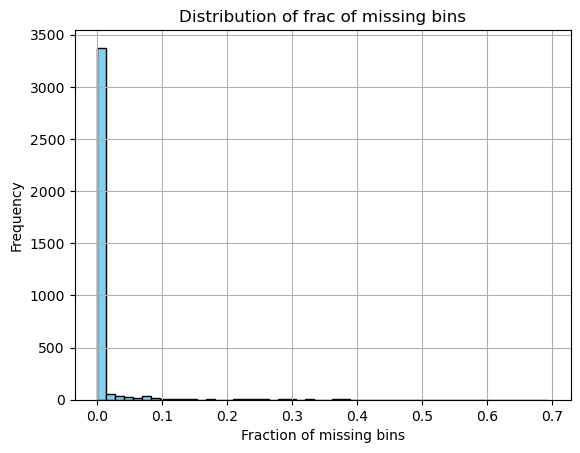

In [10]:
plt.hist(new_df["frac_missing_bbox_pm5bins_bins"], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Fraction of missing bins')
plt.ylabel('Frequency')
plt.title('Distribution of frac of missing bins')
plt.grid(True)
plt.show()

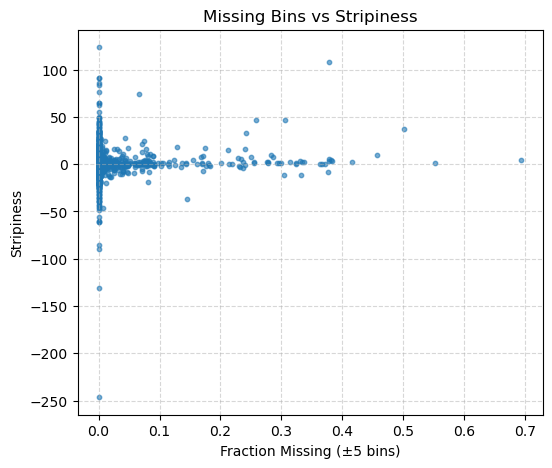

In [11]:
x = new_df["frac_missing_bbox_pm5bins_bins"]
y = new_df["Stripiness"]

plt.figure(figsize=(6,5))
plt.scatter(x, y, s=10, alpha=0.6)
plt.xlabel("Fraction Missing (±5 bins)")
plt.ylabel("Stripiness")
plt.title("Missing Bins vs Stripiness")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [12]:
selected_df = new_df[(new_df["frac_missing_bbox_pm5bins_bins"] < 0.1) & (new_df["Stripiness"] > 0)]

In [13]:
len(selected_df)

2215

In [ ]:
selected_df.columns

In [14]:
selected_df = selected_df.reset_index(drop=True)

In [15]:
# midpoints of flame in x and y direction
selected_df["x_mid"] = (selected_df["pos1"] + selected_df["pos2"]) / 2
selected_df["y_mid"] = (selected_df["pos3"] + selected_df["pos4"]) / 2

# classify position relative to diagonal
selected_df["triangular_half"] = selected_df.apply(
    lambda row: "upper" if row["y_mid"] < row["x_mid"] else "lower", axis=1
)

In [16]:
selected_df

,chr,pos1,pos2,chr2,pos3,pos4,length,width,Mean,maxpixel,pvalue,Stripiness,frac_missing_bbox_pm5bins_bins,x_mid,y_mid,triangular_half
0,chrX,99123201,99164160,chrX,99123201,100614144,1490944,40960,119.732967,95.0%,0.0765,123.556375,0.000000,99143680.5,99868672.5,lower
1,chr3,52240385,52273152,chr3,52240385,53035008,794624,32768,215.028351,99.0%,0.0040,91.015249,0.000000,52256768.5,52637696.5,lower
2,chr6,100507649,100564992,chr6,99794945,100564992,770048,57344,363.840426,99.0%,0.0030,90.817962,0.000000,100536320.5,100179968.5,upper
3,chrX,102055937,102088704,chrX,101711873,102088704,376832,32768,279.206522,99.0%,0.0665,86.172826,0.000000,102072320.5,101900288.5,upper
4,chr5,129572865,129613824,chr5,128917505,129613824,696320,40960,590.828235,99.0%,0.0020,84.147692,0.000000,129593344.5,129265664.5,upper
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2210,chr2,155262977,155295744,chr2,155262977,156073984,811008,32768,226.136364,96.0%,0.0720,0.004780,0.000000,155279360.5,155668480.5,lower
2211,chr12,54157313,54206464,chr12,54157313,54542336,385024,49152,354.000000,99.0%,0.0560,0.003913,0.000000,54181888.5,54349824.5,lower
2212,chr15,61956097,61988864,chr15,61956097,63021056,1064960,32768,101.357692,96.0%,0.0610,0.002912,0.000000,61972480.5,62488576.5,lower
2213,chr11,58777601,58802176,chr11,58777601,59080704,303104,24576,392.594595,99.0%,0.0950,0.001132,0.000000,58789888.5,58929152.5,lower


In [17]:
selected_df["window_start"] = selected_df["pos1"] - (320 * 2048) # the entire input seq is 640 bins * 2048bp per bin
selected_df["window_end"] = selected_df["pos1"] + (320 * 2048)

In [ ]:
selected_df

In [18]:
selected_df.to_csv(f"/scratch1/smaruj/stripenn_out/selected_stripes.tsv", sep="\t", index=False)

## Checking stripes with high missing bins fraction

In [ ]:
new_df[new_df["frac_missing_bbox_pm5bins_bins"] > 0.5]

In [ ]:
from matplotlib.colors import LogNorm

In [ ]:
stripes_df.columns

In [ ]:
# Get stripe info
# stripe = new_df.iloc[23494]
stripe = stripes_df.iloc[1544]
chrom = stripe['chr']

# Stripe bounds
stripe_x_start = stripe['pos1']
stripe_x_end = stripe['pos2']
stripe_y_start = stripe['pos3']
stripe_y_end = stripe['pos4']

# Stripe vertical center (x-axis) and height
stripe_x_center = (stripe_x_start + stripe_x_end) // 2
stripe_width = stripe_x_end - stripe_x_start

# We'll use the same size for X and Y to keep square view
region_size = max(stripe_width * 4, 1_000_000)  # Can adjust multiplier

# Define region so that stripe is vertically centered
region_start = stripe_x_center - region_size // 2
region_end = stripe_x_center + region_size // 2
region = f"{chrom}:{region_start}-{region_end}"

In [ ]:
# Fetch raw (unbalanced) matrix
matrix = clr.matrix(balance=False).fetch(region)

# Plot extents
extents = (region_start, region_end, region_end, region_start)

In [ ]:
# for balanced data
norm = LogNorm(vmin=1.0, vmax=1000)

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(
    matrix,
    cmap='Reds',
    norm=norm,
    extent=extents,
    origin='upper'
)

# Add rectangle or lines to show stripe
# If the stripe is vertical (typical for vertical stripe from loop extrusion):
stripe_rect = patches.Rectangle(
    (stripe_x_start, stripe_y_start),
    stripe_x_end - stripe_x_start,
    stripe_y_end - stripe_y_start,
    linewidth=2,
    edgecolor='black',
    facecolor='none'
)
plt.gca().add_patch(stripe_rect)

# plt.title(f"Stripe-centered Hi-C (raw counts)\n{region}")
plt.title(f"Stripe-centered Hi-C (balanced)\n{region}")
plt.xlabel("Genomic position (bp)")
plt.ylabel("Genomic position (bp)")
plt.colorbar(label="Contact count (log scale)")
plt.tight_layout()
plt.show()